# 004 — Natural Gas Consumption (Total Demand)

**Source:** EIA API via EIA API v2  
**File:** `data/raw/eia_consumption_monthly.csv`  
**Units:** MMcf (million cubic feet)  
**Frequency:** Monthly  
**Coverage:** 2001-01-01 to present

**Goal:** Understand total US natural gas consumption — its seasonal structure, long-run trend, and the two-season demand pattern driven by heating (winter) and power burn (summer). Consumption is the demand side of the supply/demand balance that storage summarises.

In [1]:
from pathlib import Path

# Auto-detect repository root from current working directory.
project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "data" / "raw").exists() and (parent / "notebooks").exists():
            project_root = parent
            break

print("Project root:", project_root)

Project root: C:\Users\alexd\Desktop\GIC\Prep\NatGasModel_US


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(context="paper", font_scale=2.0, style="whitegrid")

DIAG = project_root / "diagram" / "data_overview" / "004_consumption"
DIAG.mkdir(parents=True, exist_ok=True)

## 1. Load & Inspect

In [8]:
df = pd.read_csv(project_root / "data" / "raw" / "eia_consumption_monthly.csv", index_col="date", parse_dates=True)
consumption = df["consumption_mmcf"].astype(float)

print(f"Date range:   {consumption.index.min().date()} → {consumption.index.max().date()}")
print(f"Observations: {len(consumption):,}")
print(f"Missing:      {consumption.isna().sum()}")

print("\n Note: only 300 as its monthly data --> storage.diff() better")

Date range:   2001-01-01 → 2025-12-01
Observations: 300
Missing:      0

 Note: only 300 as its monthly data --> storage.diff() better


In [4]:
consumption.to_frame().sample(5).sort_index()

,consumption_mmcf
date,
2002-10-01,199288.0
2011-09-01,141634.0
2014-06-01,141451.0
2018-07-01,137574.0
2020-12-01,452878.0


In [5]:
consumption.describe().round(0)

count       300.0
mean     267437.0
std      133864.0
min      120183.0
25%      143112.0
50%      224353.0
75%      388348.0
max      609640.0
Name: consumption_mmcf, dtype: float64

## 2. Full Consumption History

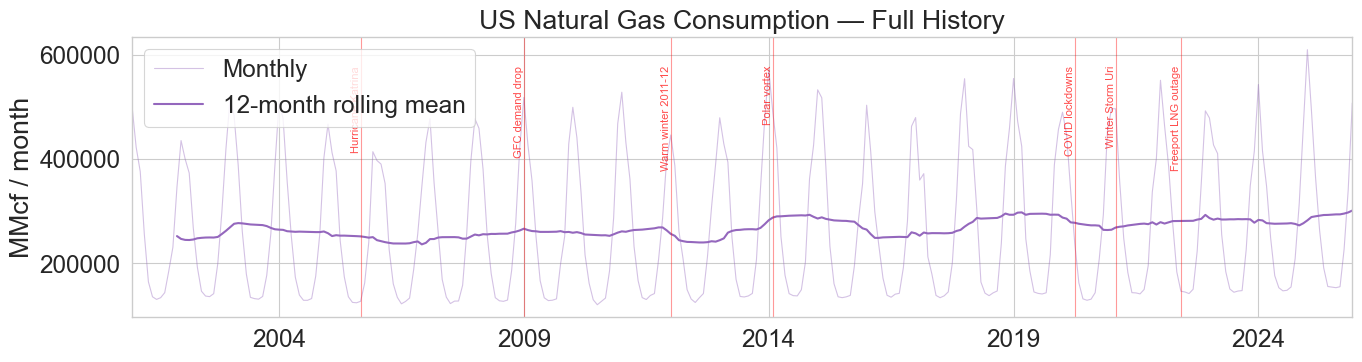

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

consumption.plot(ax=ax, color="tab:purple", alpha=0.4, linewidth=0.8, label="Monthly")
consumption.rolling(12).mean().plot(ax=ax, color="tab:purple", linewidth=1.5, label="12-month rolling mean")

events = {
    "2005-09-01": "Hurricane Katrina",
    "2009-01-01": "GFC demand drop",
    "2012-01-01": "Warm winter 2011-12",
    "2014-02-01": "Polar vortex",
    "2020-04-01": "COVID lockdowns",
    "2021-02-01": "Winter Storm Uri",
    "2022-06-01": "Freeport LNG outage",
    "2026-01-01": "US invade Venezuela",
    "2026-02-01": "US invade Iran",
}

for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), consumption.max() * 0.95),
        fontsize=8,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("US Natural Gas Consumption — Full History")
ax.set_ylabel("MMcf / month")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "consumption_full_history.svg", format="svg", bbox_inches="tight")
plt.show()

## 3. Recent Period — 2020 to Present

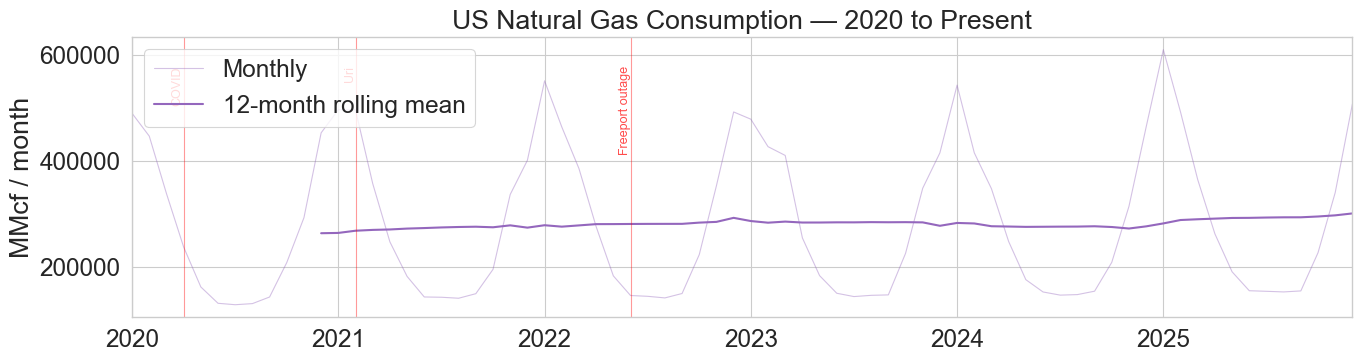

In [7]:
recent = consumption["2020":]

fig, ax = plt.subplots(figsize=(14, 4))

recent.plot(ax=ax, color="tab:purple", alpha=0.4, linewidth=0.8, label="Monthly")
recent.rolling(12).mean().plot(ax=ax, color="tab:purple", linewidth=1.5, label="12-month rolling mean")

recent_events = {
    "2020-04-01": "COVID",
    "2021-02-01": "Uri",
    "2022-06-01": "Freeport outage",
    "2026-01-01": "US invade Venezuela",
    "2026-02-01": "US invade Iran",
}

for date, label in recent_events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), recent.max() * 0.95),
        fontsize=9,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("US Natural Gas Consumption — 2020 to Present")
ax.set_ylabel("MMcf / month")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "consumption_recent_2020.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Seasonal Profile — Monthly Average

The US two-season demand pattern: a winter peak (heating) and a secondary summer peak (power burn for air conditioning). The trough is in spring/autumn when neither heating nor cooling is needed.

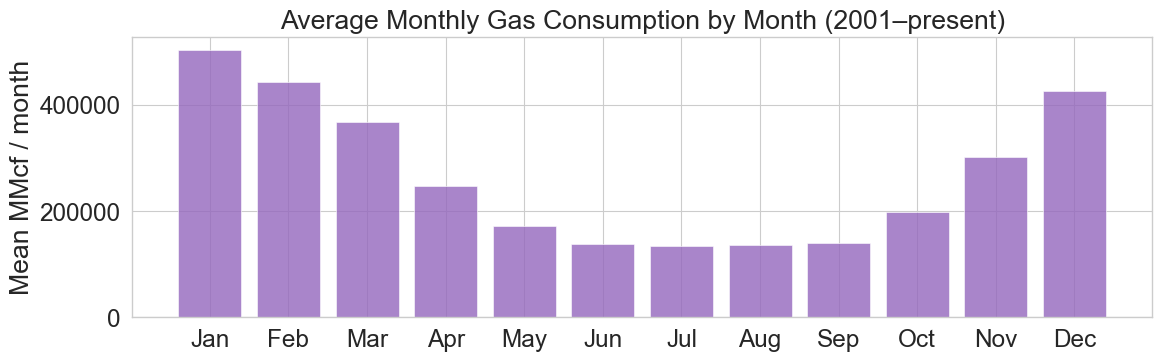

this chart is the most important one for the model to capture, as it reflects the strong seasonal pattern in demand


In [9]:
monthly_avg = consumption.groupby(consumption.index.month).mean()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    range(1, 13),
    monthly_avg.values,
    color="tab:purple",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Average Monthly Gas Consumption by Month (2001–present)")
ax.set_ylabel("Mean MMcf / month")
ax.set_xlabel("")

fig.tight_layout()
fig.savefig(DIAG / "consumption_seasonal_profile.svg", format="svg", bbox_inches="tight")
plt.show()

print("this chart is the most important one for the model to capture, as it reflects the strong seasonal pattern in demand")

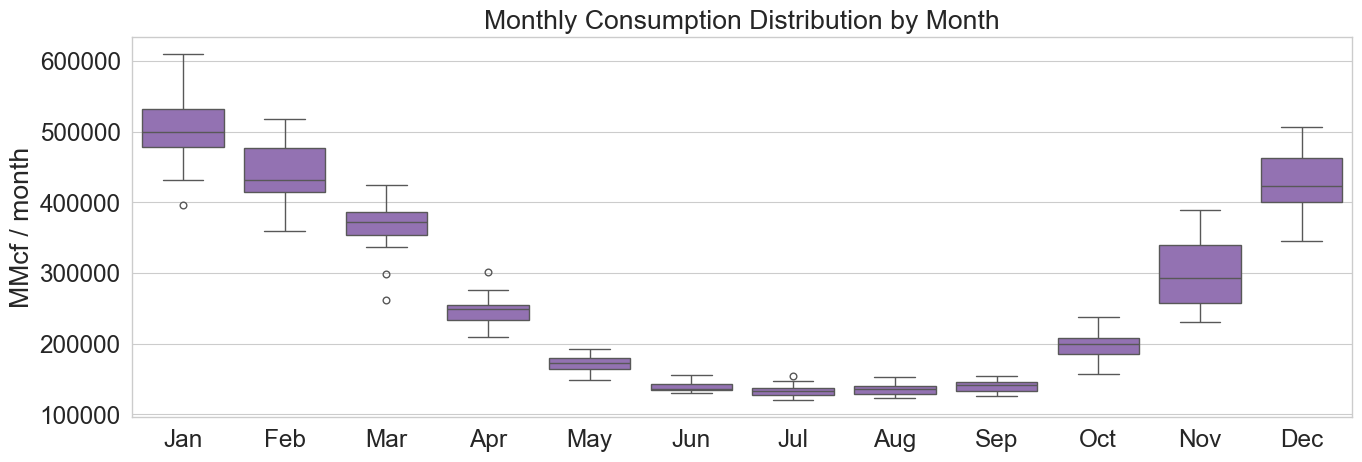

In [ ]:
# Box plot: distribution of each month across all years — shows how consistent seasonality is
consumption_df = consumption.to_frame(name="consumption_mmcf")
consumption_df["month"] = consumption_df.index.month
consumption_df["month_name"] = consumption_df["month"].apply(lambda m: month_labels[m - 1])

fig, ax = plt.subplots(figsize=(14, 5))

sns.boxplot(
    data=consumption_df,
    x="month_name",
    y="consumption_mmcf",
    order=month_labels,
    color="tab:purple",
    ax=ax,
)

ax.set_title("Monthly Consumption Distribution by Month")
ax.set_ylabel("MMcf / month")
ax.set_xlabel("")

fig.tight_layout()
fig.savefig(DIAG / "consumption_monthly_boxplot.svg", format="svg", bbox_inches="tight")
plt.show()

#basically no change in monthly consumption YoY

## 5. YoY Growth Trend

Year-over-year change reveals structural demand growth driven by LNG exports (post-2016) and power burn growth (coal-to-gas switching). Short-term deviations reflect weather and economic cycles.

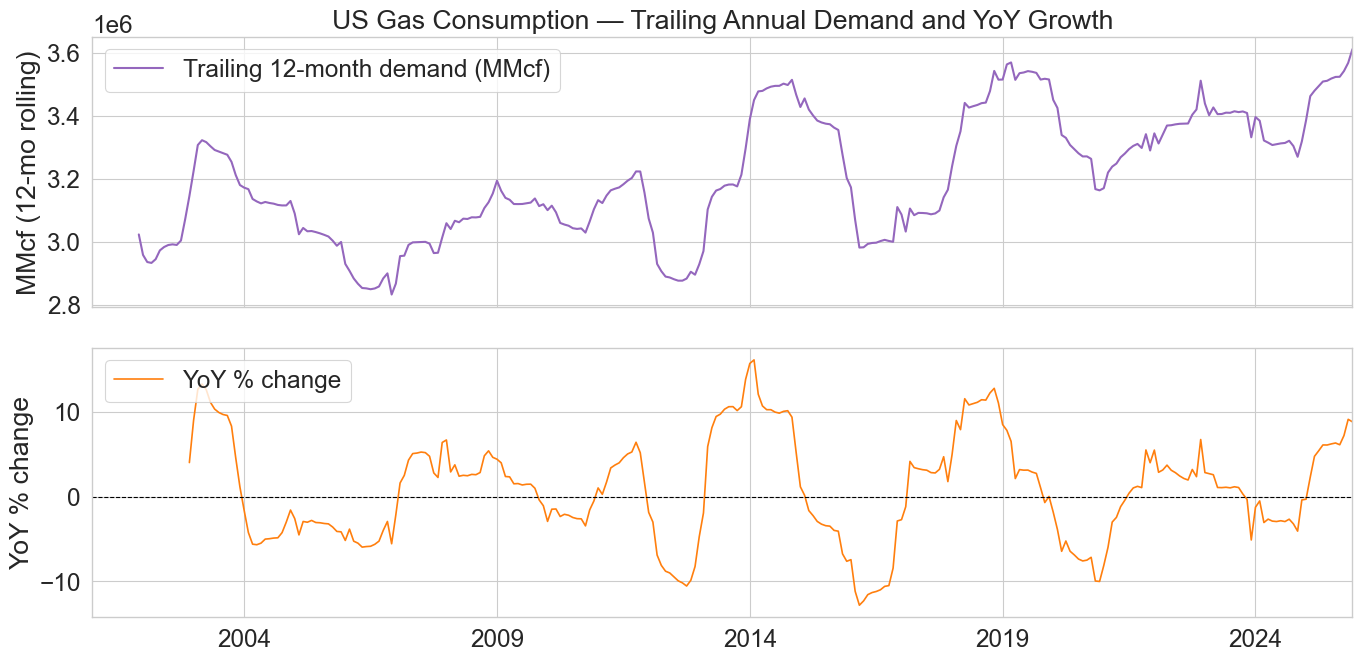

In [10]:
# 12-month rolling sum as a proxy for trailing 12-month demand
rolling_annual = consumption.rolling(12).sum()

# YoY % change on the rolling sum
yoy_change = rolling_annual.pct_change(12) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

rolling_annual.plot(ax=axes[0], color="tab:purple", linewidth=1.5, label="Trailing 12-month demand (MMcf)")
axes[0].set_ylabel("MMcf (12-mo rolling)")
axes[0].set_title("US Gas Consumption — Trailing Annual Demand and YoY Growth")
axes[0].legend(loc="upper left")

yoy_change.plot(ax=axes[1], color="tab:orange", linewidth=1.2, label="YoY % change")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("YoY % change")
axes[1].set_xlabel("")
axes[1].legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "consumption_yoy_growth.svg", format="svg", bbox_inches="tight")
plt.show()

## 6. Observations

### The two-season demand pattern

US natural gas consumption is driven by two distinct seasonal peaks — and this is structurally different from European gas markets:

- **Winter peak (Dec–Feb):** Heating demand dominates. Residential and commercial buildings use gas for space heating. The US heating season is when storage is drawn down and when the market is most sensitive to temperature deviations from normal. A colder-than-normal January can add 5–10% to monthly demand
- **Summer secondary peak (Jul–Aug):** Driven by power burn — gas-fired generation for air conditioning load, particularly in the South (Texas, Southeast). The summer peak has grown significantly since 2016 as coal plants retired and gas-fired capacity expanded. It is now comparable in magnitude to the winter peak in some years
- **Spring/autumn trough (Apr–May, Sep–Oct):** Shoulder months — mild temperatures mean neither heating nor cooling load is significant. Lowest demand months of the year. Prices typically soften as storage injections begin

The box plot shows how wide the distribution of any given month is — January consumption, for example, has a large interquartile range because weather variability drives substantial year-to-year swings.

---

### Long-run demand trend

The trailing 12-month chart shows two structural phases:

- **2001–2010:** Relatively flat total demand (~22–24 Tcf/year). Gas was expensive in the early 2000s — industrial demand was suppressed and coal remained competitive for power generation
- **2010–2024:** Structural growth phase. Three independent drivers:
  1. **Coal-to-gas switching in power generation:** Cheap shale gas made gas the lowest-cost baseload fuel. US coal generation fell from ~50% to ~20% of the grid; gas rose from ~20% to ~40%. This is a structural, largely irreversible shift
  2. **LNG export infrastructure:** Sabine Pass (2016), Corpus Christi (2019), and others created an entirely new demand category — effectively US gas is now partially exposed to global LNG pricing
  3. **Industrial demand recovery:** Cheap gas revived petrochemical, fertiliser, and manufacturing sectors that had offshored during the high-price 2000s

---

### Key event impacts

| Event | Consumption impact | Mechanism |
|---|---|---|
| Warm winter (e.g., 2011–12) | Large negative | Below-normal heating demand; no cold-weather drawdown |
| Polar vortex (Feb 2014) | Large positive spike | Extreme cold — heating demand well above normal |
| COVID lockdowns (2020) | Moderate negative | Industrial and commercial demand collapse; residential offset |
| Winter Storm Uri (Feb 2021) | Anomalous spike | Extreme heating demand + supply collapse = the worst possible scenario |
| Freeport LNG outage (Jun 2022) | Domestically neutral | Exports reduced, but domestic consumption unchanged; price fell |

---

### Consumption as a model feature

Monthly consumption is the demand-side anchor of the supply/demand balance:

- **Lagged consumption** is a useful regressor — high trailing demand tends to draw down storage and tighten the market
- **Consumption deviations from seasonal normal** (weather-driven surprises) are correlated with storage surprises and price moves
- **The power burn component** is the most interesting for forecasting: it is driven by temperature (cooling degree days) and electricity prices, and it competes with LNG exports for available gas — the market sometimes has to ration between domestic power burn and export demand

The YoY growth rate captures structural demand shifts (coal-to-gas, LNG buildout) that a simple seasonal model would miss. Including a demand growth trend term is important for any model deployed over a multi-year forecast horizon.

---

### What's missing from total consumption alone

The single `consumption_mmcf` column is total demand. For a richer model, sectoral breakdown matters:

- **Residential + commercial** = heating demand proxy (highly weather-driven)
- **Electric power** = power burn (weather + electricity price driven; summer peak)
- **Industrial** = relatively stable, GDP-linked
- **Pipeline & lease** = operational, quasi-fixed

If sectoral data is later pulled via the EIA API (series IDs in `data_sources.md`), the electric power component (`N3045`) would be the most valuable additional feature — it is the sector where gas demand is most elastic to price and temperature.